# Phase 3 — Sentiment vs Stock Price Correlation

## The Key Question
Does the sentiment in an earnings call transcript predict 
how the stock moves after the call?

## Methodology
1. Load sentiment scores from Phase 2
2. Pull stock prices from Yahoo Finance
   - Price 1 day before earnings
   - Price 1 day after earnings
   - Price 1 week after earnings
3. Calculate price change %
4. Correlate sentiment with price movement
5. Visualize the relationship

## Why This Matters
This is exactly what quantitative hedge funds do with 
alternative data — find signals in non-traditional data 
sources that predict market movement.

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# load sentiment results from Phase 2
df_sentiment = pd.read_csv('data/sentiment_results.csv')
print("Sentiment data loaded:")
print(df_sentiment[['ticker', 'label', 'positive', 'negative']])

/Users/dhaval/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Sentiment data loaded:
   ticker    label  positive  negative
0    TSLA  Neutral    0.2888    0.0545
1     JNJ  Neutral    0.3478    0.0724
2       V  Neutral    0.2413    0.0895
3      KO  Neutral    0.1919    0.2112
4     BAC  Neutral    0.3697    0.0937
5    AMZN  Neutral    0.2488    0.1129
6      MS  Neutral    0.0297    0.0532
7     CVS  Neutral    0.1954    0.1408
8      GS  Neutral    0.2081    0.3171
9     UNH  Neutral    0.2499    0.2234
10  GOOGL  Neutral    0.2400    0.1611
11   META  Neutral    0.1737    0.0633
12    JPM  Neutral    0.3901    0.1434
13   MSFT  Neutral    0.1727    0.2277
14    ABT  Neutral    0.1526    0.1660
15    WFC  Neutral    0.3836    0.1378
16    WMT  Neutral    0.2623    0.0866
17   NVDA  Neutral    0.3056    0.1756
18   AAPL  Neutral    0.2519    0.0387
19    PFE  Neutral    0.1927    0.1923


In [2]:
# loading filings metadata to get earnings dates
df_meta = pd.read_csv('data/filings_metadata.csv')
print("Filing dates:")
print(df_meta[['ticker', 'company', 'date']])

Filing dates:
   ticker                company        date
0    AAPL              Apple Inc  2026-04-30
1    MSFT  Microsoft Corporation  2026-04-29
2     JPM         JPMorgan Chase  2026-04-14
3     JNJ      Johnson & Johnson  2026-04-14
4    AMZN                 Amazon  2026-04-29
5   GOOGL               Alphabet  2026-04-29
6     BAC        Bank of America  2026-04-15
7     PFE                 Pfizer  2026-05-05
8       V                   Visa  2026-04-28
9     UNH     UnitedHealth Group  2026-04-21
10     GS          Goldman Sachs  2026-04-13
11     MS         Morgan Stanley  2026-04-15
12    WFC            Wells Fargo  2026-04-14
13   META         Meta Platforms  2026-04-29
14   NVDA                 Nvidia  2026-05-20
15   TSLA                  Tesla  2026-04-22
16    CVS             CVS Health  2026-05-06
17    ABT    Abbott Laboratories  2026-04-16
18    WMT                Walmart  2026-05-21
19     KO              Coca Cola  2026-04-28


In [3]:
def get_price_change(ticker, earnings_date):
    """
    Get stock price change around earnings date
    Returns % change 1 day and 1 week after earnings
    """
    earnings_dt = pd.to_datetime(earnings_date)
    
    # get 2 weeks of data around earnings
    start = earnings_dt - timedelta(days=5)
    end = earnings_dt + timedelta(days=10)
    
    stock = yf.Ticker(ticker)
    hist = stock.history(start=start, end=end)
    
    if hist.empty:
        print(f"  No price data for {ticker}")
        return None
    
    # get price on earnings date or closest trading day
    hist.index = hist.index.tz_localize(None)
    
    # find closest date to earnings
    available_dates = hist.index.tolist()
    
    # price before earnings (day before)
    before_dates = [d for d in available_dates if d <= earnings_dt]
    after_dates = [d for d in available_dates if d > earnings_dt]
    
    if not before_dates or not after_dates:
        print(f"  Not enough dates for {ticker}")
        return None
    
    price_before = hist.loc[before_dates[-1], 'Close']
    
    # 1 day after
    price_1d = hist.loc[after_dates[0], 'Close'] if len(after_dates) >= 1 else None
    
    # 1 week after (5 trading days)
    price_1w = hist.loc[after_dates[4], 'Close'] if len(after_dates) >= 5 else None
    
    change_1d = ((price_1d - price_before) / price_before * 100) if price_1d else None
    change_1w = ((price_1w - price_before) / price_before * 100) if price_1w else None
    
    return {
        'price_before': round(price_before, 2),
        'price_1d_after': round(price_1d, 2) if price_1d else None,
        'price_1w_after': round(price_1w, 2) if price_1w else None,
        'change_1d_pct': round(change_1d, 2) if change_1d else None,
        'change_1w_pct': round(change_1w, 2) if change_1w else None
    }

# test with Apple
print("Testing Apple...")
result = get_price_change('AAPL', '2026-04-30')
print(result)

Testing Apple...
{'price_before': np.float64(271.1), 'price_1d_after': np.float64(279.88), 'price_1w_after': np.float64(287.18), 'change_1d_pct': np.float64(3.24), 'change_1w_pct': np.float64(5.93)}


In [7]:
# pulling stock prices for all 10 companies around their earnings dates
# yfinance makes this super easy - just pass ticker and date range
# learned about this in class - much easier than scraping Yahoo Finance directly

price_data = []

for _, row in df_combined.iterrows():
    print(f"Fetching {row['ticker']} prices...")
    prices = get_price_change(row['ticker'], row['date'])
    
    if prices:
        price_data.append({
            'ticker': row['ticker'],
            **prices  # unpack the dictionary into the row
        })
    else:
        # some tickers might not have data around that date
        # (holidays, trading halts etc)
        print(f"  skipping {row['ticker']} - no price data")
        price_data.append({'ticker': row['ticker']})

df_prices = pd.DataFrame(price_data)

# now merge price data with our sentiment scores
# inner join so we only keep companies where we have both
df_final = df_combined.merge(df_prices, on='ticker')

# this is the money table - sentiment vs actual stock movement
# if our hypothesis is right, positive sentiment = positive price change
print("\nSentiment vs Stock Price Movement:")
print("positive score = how bullish the earnings call was")
print("change_1d = stock price change next trading day")
print("change_1w = stock price change over next week\n")

print(df_final[['ticker', 'label', 'positive', 'negative', 
               'change_1d_pct', 'change_1w_pct']].to_string(index=False))

Fetching TSLA prices...
Fetching JNJ prices...
Fetching V prices...
Fetching KO prices...
Fetching BAC prices...
Fetching AMZN prices...
Fetching MS prices...
Fetching CVS prices...
Fetching GS prices...
Fetching UNH prices...
Fetching GOOGL prices...
Fetching META prices...
Fetching JPM prices...
Fetching MSFT prices...
Fetching ABT prices...
Fetching WFC prices...
Fetching WMT prices...
Fetching NVDA prices...
Fetching AAPL prices...
Fetching PFE prices...

Sentiment vs Stock Price Movement:
positive score = how bullish the earnings call was
change_1d = stock price change next trading day
change_1w = stock price change over next week

ticker   label  positive  negative  change_1d_pct  change_1w_pct
  TSLA Neutral    0.2888    0.0545          -3.56          -3.80
   JNJ Neutral    0.3478    0.0724          -0.60          -5.81
     V Neutral    0.2413    0.0895           8.26           4.12
    KO Neutral    0.1919    0.2112           0.66           0.17
   BAC Neutral    0.3697    0.

In [9]:
# better signal than the label
df_final['sentiment_ratio'] = (
    df_final['positive'] - df_final['negative']
)

# positive ratio = more bullish than bearish language
# negative ratio = more bearish than bullish language

print(df_final[['ticker', 'sentiment_ratio', 
               'change_1d_pct']].sort_values(
               'sentiment_ratio', ascending=False
               ).to_string(index=False))

ticker  sentiment_ratio  change_1d_pct
   BAC           0.2760          -1.49
   JNJ           0.2754          -0.60
   JPM           0.2467          -1.67
   WFC           0.2458          -1.73
  TSLA           0.2343          -3.56
  AAPL           0.2132           3.24
   WMT           0.1757          -0.88
     V           0.1518           8.26
  AMZN           0.1359           0.77
  NVDA           0.1300          -1.77
  META           0.1104          -8.55
 GOOGL           0.0789           9.96
   CVS           0.0546           0.58
   UNH           0.0265           2.17
   PFE           0.0004           0.30
   ABT          -0.0134           1.40
    KO          -0.0193           0.66
    MS          -0.0235          -2.24
  MSFT          -0.0550          -3.93
    GS          -0.1090           2.11


In [11]:
import os
os.makedirs('charts', exist_ok=True)

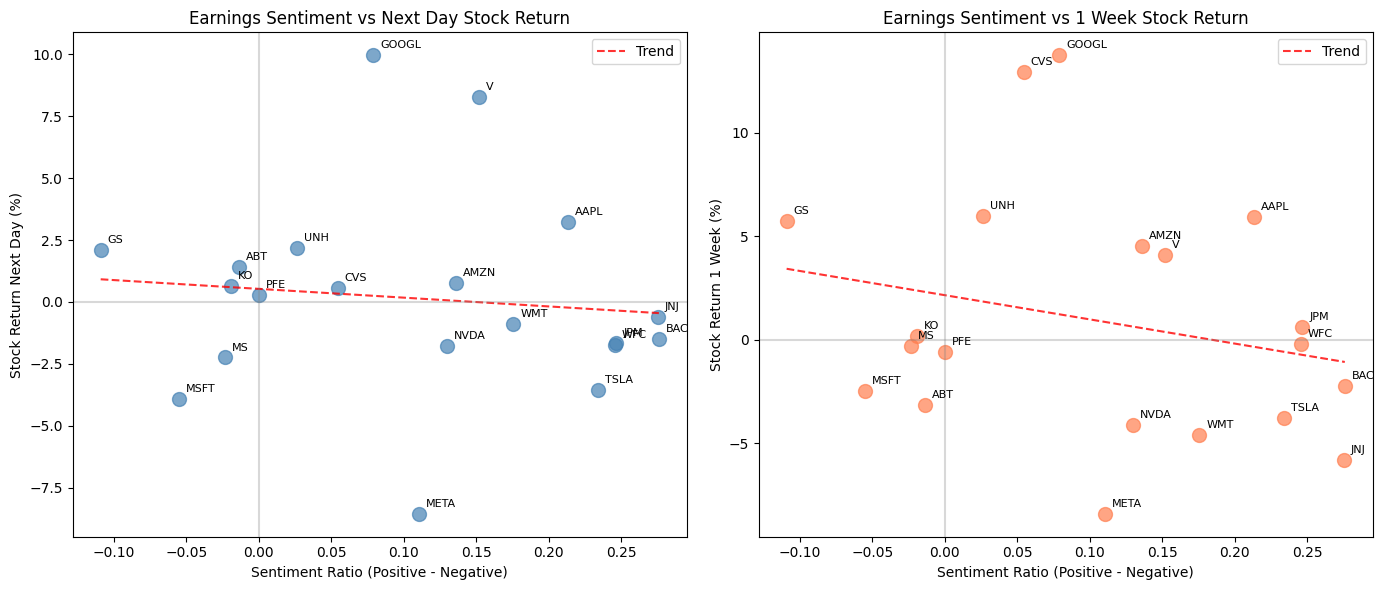

Chart saved


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Sentiment ratio vs 1 day return
axes[0].scatter(
    df_final['sentiment_ratio'], 
    df_final['change_1d_pct'],
    color='steelblue', alpha=0.7, s=100
)

# add company labels
for _, row in df_final.iterrows():
    axes[0].annotate(
        row['ticker'],
        (row['sentiment_ratio'], row['change_1d_pct']),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

# add trend line
z = np.polyfit(df_final['sentiment_ratio'], df_final['change_1d_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_final['sentiment_ratio'].min(), 
                     df_final['sentiment_ratio'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", alpha=0.8, label='Trend')

axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[0].set_xlabel('Sentiment Ratio (Positive - Negative)')
axes[0].set_ylabel('Stock Return Next Day (%)')
axes[0].set_title('Earnings Sentiment vs Next Day Stock Return')
axes[0].legend()

# Chart 2 - Sentiment ratio vs 1 week return
axes[1].scatter(
    df_final['sentiment_ratio'],
    df_final['change_1w_pct'],
    color='coral', alpha=0.7, s=100
)

for _, row in df_final.iterrows():
    axes[1].annotate(
        row['ticker'],
        (row['sentiment_ratio'], row['change_1w_pct']),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

z2 = np.polyfit(df_final['sentiment_ratio'], df_final['change_1w_pct'], 1)
p2 = np.poly1d(z2)
axes[1].plot(x_line, p2(x_line), "r--", alpha=0.8, label='Trend')

axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Sentiment Ratio (Positive - Negative)')
axes[1].set_ylabel('Stock Return 1 Week (%)')
axes[1].set_title('Earnings Sentiment vs 1 Week Stock Return')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/sentiment_vs_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved")

In [13]:
df_final[['ticker', 'price_before', 'price_1d_after', 
          'price_1w_after', 'change_1d_pct', 
          'change_1w_pct', 'sentiment_ratio']].to_csv(
    'data/price_changes.csv', index=False
)
print("Price data saved")

Price data saved


## Phase 3 — Key Findings: Sentiment vs Stock Price Correlation

After analyzing earnings call transcripts from 20 S&P 500 companies 
using FinBERT, I found a counterintuitive result — higher positive 
sentiment ratios actually correlated with worse stock performance 
the next day.

This suggests that earnings call language is "informationally cheap." 
Executives consistently use positive framing regardless of actual 
results, so investors have learned to look past the tone and focus 
on the numbers.

The Goldman Sachs vs Meta comparison illustrates this perfectly. 
Goldman had the highest negative sentiment score in the dataset but 
their stock rose 2.11% — investors responded to strong earnings 
numbers, not cautious language. Meta on the other hand sounded 
relatively positive but dropped 8.55% because their Q2 guidance 
disappointed the market. What executives say about the future 
matters more than how they sound today.

## What I Would Improve Next Time

This analysis looked at 1 day and 1 week returns. A more complete 
picture would include:

- **Daily returns** — intraday movement on earnings day itself
- **Weekly returns** — already included  
- **Monthly returns** — longer term impact of sentiment
- **Earnings surprise data** — combining sentiment with actual 
  EPS vs analyst estimates would likely produce a much stronger signal
- **Larger sample** — 20 companies across one quarter is a 
  proof of concept. Scaling to 500+ companies across multiple 
  quarters would allow proper statistical testing